In [1]:
from simulation_functions import *

from tqdm.notebook import tqdm

In [2]:
import numpy as np
import random as rnd

from copy import deepcopy

import matplotlib.pyplot as plt

In [3]:
from simulation_functions import *
from utils_analysis_for_simulation import *

c:\Users\Utente\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Utente\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


# Plot styles

In [4]:
plt.style.use("seaborn-whitegrid")
import matplotlib as mpl

mpl.rcParams.update({
    # Font
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    
    # Axes and grid
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Lines and markers
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Default colormap for images
    "image.cmap": "Blues",

    # Default color cycle for plots
    "axes.prop_cycle": plt.cycler(
        color=[
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
        ]
    ),

    # Figure
#     "figure.figsize": (6, 4),
#     "figure.dpi": 150,

    # Legend
    "legend.frameon": False,
})

mpl.rcParams["patch.force_edgecolor"] = True

In [7]:
Number_of_news=10
News_items=[]

Distribution_news=uniform_distr(POSSIBLE_STANCES)

Number_of_readers=1000
Readers=[]

In [8]:
RESULTS_STATIC=load_results(['RK2v3','RK2v4'])

weight_ranking_bias, Distribution_readers, C, H = results_to_simulation_inputs(RESULTS_STATIC, 
                                             lambda z: z<3,
                                             topic_i=None,
                                             plot=False,
                                             apply_droprule=False,
                                             drop_rules=None,
                                            )
Behavior_clicking=C.T
Behavior_highlighting=H.T

RK2v3
RK2v4
Number of valid entries: 431


C:\Users\Utente\AppData\Local\Temp\ipykernel_28332\1047820480.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()
C:\Users\Utente\AppData\Local\Temp\ipykernel_28332\1047820480.py:25: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


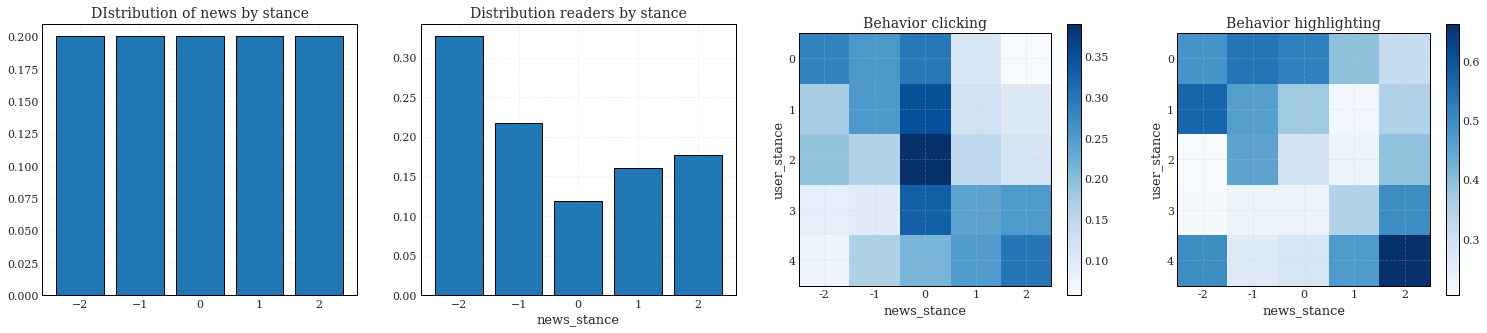

In [12]:
plt.figure(figsize=(26,5))
plt.subplot(1,4,1)
plt.title("DIstribution of news by stance")
plt.bar(POSSIBLE_STANCES, Distribution_news)
plt.subplot(1,4,1+1)
plt.title("Distribution readers by stance")
plt.bar(POSSIBLE_STANCES, Distribution_readers)
# plt.xticks(range(0,5), range(-2,3))
plt.xlabel("news_stance")
plt.subplot(1,4,2+1)
plt.title("Behavior clicking")
plt.imshow(Behavior_clicking)
plt.ylabel("user_stance")
plt.xticks(range(0,5), range(-2,3))
plt.xlabel("news_stance")
plt.xticks(range(0,5), range(-2,3))
plt.colorbar()
plt.subplot(1,4,3+1)
plt.title("Behavior highlighting")
plt.imshow(Behavior_highlighting)
plt.ylabel("user_stance")
plt.xticks(range(0,5), range(-2,3))
plt.xlabel("news_stance")
plt.xticks(range(0,5), range(-2,3))
plt.colorbar()

# 1000 repetitions with 1000 interactions (time)

In [ ]:
REPETITIONS_PER_EXPERIMENT=1000
TURNS=1000

METRIC_WINDOW=200

In [15]:
for case in [1,2]:
    if case==1:
        weight_popularity_highlight=0
        weight_other_partition=1
    if case==2:
        weight_popularity_highlight=100
        weight_other_partition=0
        
    EVENTS=[]
    POPULARITIES=[]

    for iteration in tqdm(range(REPETITIONS_PER_EXPERIMENT)):
        # Initial_popularity=Initialize_popularity(News_items)

        News_items, Readers, Perception_matrix_all, Initial_popularity = Initialize(Number_of_news, Distribution_news, 
                                                                                    Number_of_readers, Distribution_readers, 
                                                                                    ASSUME_PERFECT_PERCEPTION=True, Perception_matrix=None)


        events, Popularity= run(
            Readers, News_items, 
            Initial_popularity, 
            Perception_matrix_all, 
            Behavior_clicking, Behavior_highlighting,
            weight_ranking_bias, weight_popularity_highlight, weight_other_partition,
            TURNS
            )
        EVENTS.append(events)
        POPULARITIES.append(Popularity)

#     events_to_conf_matrices(EVENTS)
#     events_to_distributions(EVENTS, merge_by_size=None)
#     popularity_series_to_avgrank(POPULARITIES, News_items)

#     EXTREMISM_BASELINE=np.mean([
#         np.abs(rnd_stance) for rnd_stance in rnd.choices(POSSIBLE_STANCES, k=len(Readers), weights=Distribution_news)
#     ])
#     POLARIZATION_BASELINE=0

    EXTREMISM=events_to_extremism(EVENTS, baseline=None, return_data=True, plot=False)
    EXTREMISM=np.array(EXTREMISM)
#     EXTREMISM_STANCEWISE=events_to_extremism_stancewise(EVENTS, return_data=True)

    POLARIZATION=events_to_polarization(EVENTS, baseline=None, return_data=True, plot=False)
    POLARIZATION=np.array(POLARIZATION)
    
    if case==1:
        ext_avg_1=EXTREMISM.mean(axis=0)
        ext_std_1=EXTREMISM.std(axis=0)
        pol_avg_1=POLARIZATION.mean(axis=0)
        pol_std_1=POLARIZATION.std(axis=0)
    if case==2:
        ext_avg_2=EXTREMISM.mean(axis=0)
        ext_std_2=EXTREMISM.std(axis=0)
        pol_avg_2=POLARIZATION.mean(axis=0)
        pol_std_2=POLARIZATION.std(axis=0)

  0%|          | 0/1000 [00:00<?, ?it/s]

c:\Users\Utente\OneDrive\Desktop\TO SHARE\CODE_SIMULATIONS\simulation_functions.py:775: RuntimeWarning: Mean of empty slice
  smoothed_values=[np.nanmean(values[max(0,i-window):i]) for i in range(len(values))]
c:\Users\Utente\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Utente\anaconda3\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | 0/1000 [00:00<?, ?it/s]

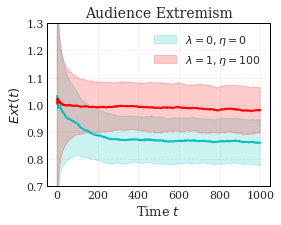

In [21]:
plt.figure(figsize=(4,3))
plt.plot(ext_avg_1, color='c')
plt.fill_between(range(len(ext_avg_1)), ext_avg_1-ext_std_1, ext_avg_1+ext_std_1, color="c", alpha=0.2, label="$\lambda=0, \eta=0$")
plt.plot(ext_avg_2, color='r')
plt.fill_between(range(len(ext_avg_2)), ext_avg_2-ext_std_2, ext_avg_2+ext_std_2, color="r", alpha=0.2, label="$\lambda=1, \eta=100$")
plt.ylim(0.7,1.3)
plt.legend()
# plt.grid()
plt.title("Audience Extremism")
plt.xlabel("Time $t$")
plt.ylabel("$Ext(t)$")
plt.savefig(f'time_extremism.pdf', bbox_inches='tight')
# plt.savefig(f'../Figures/time_extremism.pdf', bbox_inches='tight')



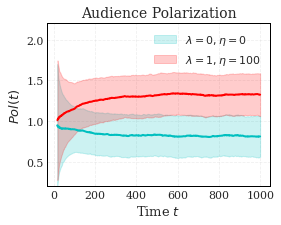

In [20]:
plt.figure(figsize=(4,3))
plt.plot(pol_avg_1, color='c')
plt.fill_between(range(len(pol_avg_1)), pol_avg_1-pol_std_1, pol_avg_1+pol_std_1, color="c", alpha=0.2, label="$\lambda=0, \eta=0$")
plt.plot(pol_avg_2, color='r')
plt.fill_between(range(len(pol_avg_2)), pol_avg_2-pol_std_2, pol_avg_2+pol_std_2, color="r", alpha=0.2, label="$\lambda=1, \eta=100$")
plt.ylim(0.2,2.2)
plt.legend()
# plt.grid()
plt.title("Audience Polarization")
plt.xlabel("Time $t$")
plt.ylabel("$Pol(t)$")
plt.savefig(f'time_polarization.pdf', bbox_inches='tight')
# plt.savefig(f'../Figures/time_polarization.pdf', bbox_inches='tight')

# Grid simulation

In [32]:
reset_timers()

In [ ]:
Final_extremism_avg={}
Final_extremism_std={}
Final_extremism_all_avg={}
Final_extremism_all_std={}
Final_polarization_avg={}
Final_polarization_std={}
Final_click_density={}
Final_extremism_stancewise_avg=[{} for _ in POSSIBLE_STANCES]
Final_extremism_stancewise_std=[{} for _ in POSSIBLE_STANCES]
Final_stancewise_avgrank_avg={p:{s: {} for s in POSSIBLE_STANCES} for p in [-1,0,1]}
Final_stancewise_avgrank_std={p:{s: {} for s in POSSIBLE_STANCES} for p in [-1,0,1]}

TEST_LAMBDA=np.linspace(0,1,11)#[0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
# TEST_ETA=np.linspace(0,100,11)#[0,0.05, 0.1,0.4,0.7,1,1.4,1.8, 2.3, 2.8, 3.5,4.5, 7, 9, 12, 15, 20, 28, 40, 70, 100]
TEST_ETA=[0]+np.logspace(0,np.log2(100),10, base=2).tolist()

for weight_other_partition in tqdm(TEST_LAMBDA):
    Final_extremism_avg[weight_other_partition]={}
    Final_extremism_std[weight_other_partition]={}
    Final_extremism_all_avg[weight_other_partition]={}
    Final_extremism_all_std[weight_other_partition]={}
    Final_polarization_avg[weight_other_partition]={}
    Final_polarization_std[weight_other_partition]={}
    Final_click_density[weight_other_partition]={}

    for s in POSSIBLE_STANCES:
        Final_extremism_stancewise_avg[s2idx[s]][weight_other_partition]={}
        Final_extremism_stancewise_std[s2idx[s]][weight_other_partition]={}
        for p in [-1,0,1]:
            Final_stancewise_avgrank_avg[p][s][weight_other_partition]={}
            Final_stancewise_avgrank_std[p][s][weight_other_partition]={}

    for weight_popularity_highlight in tqdm(TEST_ETA):
        W_EVENTS=[]
        W_POPULARITIES=[]

        for iteration in range(REPETITIONS_PER_EXPERIMENT):
            News_items, Readers, Perception_matrix_all, Initial_popularity = Initialize(Number_of_news, Distribution_news, 
                                                                                Number_of_readers, Distribution_readers, 
                                                                                ASSUME_PERFECT_PERCEPTION=True, Perception_matrix=None)

            events, Popularity= run(
                    Readers, News_items,
                    Initial_popularity, 
                    Perception_matrix_all, Behavior_clicking, Behavior_highlighting,
                    weight_ranking_bias, 
                    weight_popularity_highlight, #<----- parameter that changes
                    weight_other_partition, #<----- parameter that changes
                    TURNS, 
            )
            W_EVENTS.append(events)
            W_POPULARITIES.append(Popularity)

        W_EXTREMISM=events_to_extremism(W_EVENTS, IGNORE_NEUTRAL_READERS=True, window=METRIC_WINDOW, return_data=True, plot=False)
        Final_extremism_avg[weight_other_partition][weight_popularity_highlight]=np.mean([iteration_extremism[-1] for iteration_extremism in W_EXTREMISM])
        Final_extremism_std[weight_other_partition][weight_popularity_highlight]=np.std([iteration_extremism[-1] for iteration_extremism in W_EXTREMISM])
        
        W_EXTREMISM_ALL=events_to_extremism(W_EVENTS, IGNORE_NEUTRAL_READERS=False, window=METRIC_WINDOW, return_data=True, plot=False)
        Final_extremism_all_avg[weight_other_partition][weight_popularity_highlight]=np.mean([iteration_extremism[-1] for iteration_extremism in W_EXTREMISM_ALL])
        Final_extremism_all_std[weight_other_partition][weight_popularity_highlight]=np.std([iteration_extremism[-1] for iteration_extremism in W_EXTREMISM_ALL])
        

        W_POLARIZATION=events_to_polarization(W_EVENTS, window=METRIC_WINDOW, return_data=True, plot=False)
        Final_polarization_avg[weight_other_partition][weight_popularity_highlight]=np.mean([iteration_polarization[-1] for iteration_polarization in W_POLARIZATION])
        Final_polarization_std[weight_other_partition][weight_popularity_highlight]=np.std([iteration_polarization[-1] for iteration_polarization in W_POLARIZATION])

        W_EXTREMISM_STANCEWISE=events_to_extremism_stancewise(W_EVENTS, window=METRIC_WINDOW, return_data=True, plot=False)
        for s, w_extremism_stancewise in enumerate(W_EXTREMISM_STANCEWISE):
            Final_extremism_stancewise_avg[s][weight_other_partition][weight_popularity_highlight]=\
                np.nanmean([iteration_extremism_stancewise[-1] for iteration_extremism_stancewise in w_extremism_stancewise])
        

        W_CLICK_DENSITY=events_to_click_density(W_EVENTS, return_data=True, plot=False)
        Final_click_density[weight_other_partition][weight_popularity_highlight]=W_CLICK_DENSITY
        
        W_STANCEWISE_AVGRANG=populatities_to_stancewise_avgrank(W_POPULARITIES, News_items,
                                                                final_value_only=True, #<---- to save computation time
                                                                return_data=True, plot=False)
        for p in [-1,0,1]:
            for s in POSSIBLE_STANCES:
                Final_stancewise_avgrank_avg[p][s][weight_other_partition][weight_popularity_highlight]=\
                W_STANCEWISE_AVGRANG[0][p][s][-1]
                Final_stancewise_avgrank_std[p][s][weight_other_partition][weight_popularity_highlight]=\
                W_STANCEWISE_AVGRANG[1][p][s][-1]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

In [42]:
dir_timers()

  Latest run timer info:

    initialize_altogether__________________________________:____________1.046386_min.
    run____________________________________________________:__________251.458799_min.
    ___clicking_probabilities______________________________:___________42.405915_min.
    ___highlighting_probabilities__________________________:____________2.410232_min.
    metrics________________________________________________:__________765.748003_min.


# Save data

In [51]:
DATA_SAVE={
    'TEST_LAMBDA':TEST_LAMBDA,
    'TEST_ETA':TEST_ETA,
    'Final_extremism_avg':Final_extremism_avg,
    'Final_extremism_std':Final_extremism_std,
    'Final_extremism_all_avg':Final_extremism_all_avg,
    'Final_extremism_all_std':Final_extremism_all_std,
    'Final_polarization_avg':Final_polarization_avg,
    'Final_polarization_std':Final_polarization_std,
    'Final_click_density':Final_click_density,
    'Final_extremism_stancewise_avg':Final_extremism_stancewise_avg,
    'Final_extremism_stancewise_std':Final_extremism_stancewise_std,
    'Final_stancewise_avgrank_avg':Final_stancewise_avgrank_avg,
    'Final_stancewise_avgrank_std':Final_stancewise_avgrank_std, 
}

import pickle

# Save to file
with open('simulation_grid_data.pkl', 'wb') as f:
    pickle.dump(DATA_SAVE, f)

# Plots of the manuscript generated in simulation_grid_plots.ipynb

In [43]:
E_avg=[]
E_std=[]

for eta, data in Final_extremism_avg.items():
    E_avg.append([])
    E_std.append([])
    for lmb, extremism in data.items():
        E_avg[-1].append(extremism)
        E_std[-1].append(Final_extremism_std[eta][lmb])

In [ ]:
1-np.array(TEST_LAMBDA).round(1)

C:\Users\Utente\AppData\Local\Temp\ipykernel_20860\4102319854.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


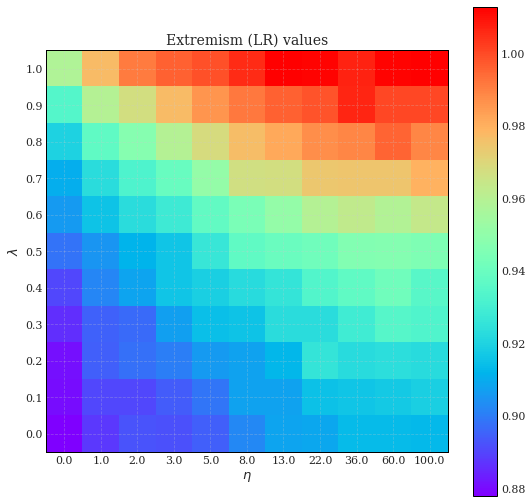

In [44]:
plt.figure(figsize=(9,9))
plt.title("Extremism (LR) values")
plt.imshow(E_avg, cmap='rainbow')
plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
plt.ylabel('$\lambda$')
plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(0))
plt.xlabel('$\eta$')
plt.colorbar()
# contour plot
plt.savefig(f'../Figures/png/extremism_lr_grid.png')
plt.savefig(f'../Figures/extremism_lr_grid.pdf')

C:\Users\Utente\AppData\Local\Temp\ipykernel_20860\128093535.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


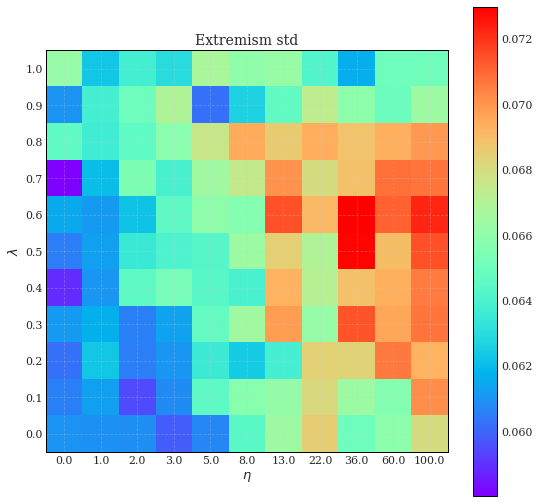

In [45]:
plt.figure(figsize=(9,9))
plt.title("Extremism std")
plt.imshow(E_std, cmap='rainbow')
plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
plt.ylabel('$\lambda$')
plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(0))
plt.xlabel('$\eta$')
plt.colorbar()
plt.savefig(f'../Figures/png/extremism_grid_std.png')
plt.savefig(f'../Figures/extremism_grid_std.pdf')

In [46]:
Ea_avg=[]
Ea_std=[]

for eta, data in Final_extremism_all_avg.items():
    Ea_avg.append([])
    Ea_std.append([])
    for lmb, extremism in data.items():
        Ea_avg[-1].append(extremism)
        Ea_std[-1].append(Final_extremism_all_std[eta][lmb])

C:\Users\Utente\AppData\Local\Temp\ipykernel_20860\3232030297.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


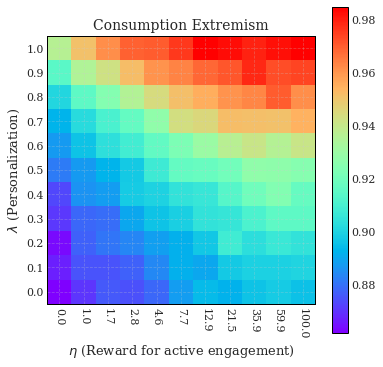

In [47]:
plt.figure(figsize=(6,6))
plt.title("Consumption Extremism")
plt.imshow(Ea_avg, cmap='rainbow')
plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
plt.ylabel('$\lambda$ (Personalization)')
plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(1), rotation=-90)
plt.xlabel('$\eta$ (Reward for active engagement)')
plt.colorbar()
plt.savefig(f'../Figures/png/extremism_all_grid.png')
plt.savefig(f'../Figures/extremism_all_grid.pdf')

In [ ]:
plt.figure(figsize=(14,8))
for s in POSSIBLE_STANCES:
    SEa_avg=[]
    # SEa_std=[]
    for eta, data in Final_extremism_stancewise_avg[s2idx[s]].items():
        SEa_avg.append([])
        # SEa_std.append([])
        for lmb, extremism in data.items():
            SEa_avg[-1].append(extremism)
            # SEa_std[-1].append(Final_extremism_stancewise_avg[s][eta][lmb])
    plt.subplot(2,3,s2idx[s]+1)
    plt.title(f"Attention Extremism {s}")
    plt.imshow(SEa_avg, cmap='rainbow')
    plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
    plt.ylabel('$\lambda$')
    plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(0), rotation=90)
    plt.xlabel('$\eta$')
    plt.colorbar()
plt.tight_layout()

In [ ]:
P_avg=[]
P_std=[]

for eta, data in Final_polarization_avg.items():
    P_avg.append([])
    P_std.append([])
    for lmb, polarization in data.items():
        P_avg[-1].append(polarization)
        P_std[-1].append(Final_polarization_std[eta][lmb])

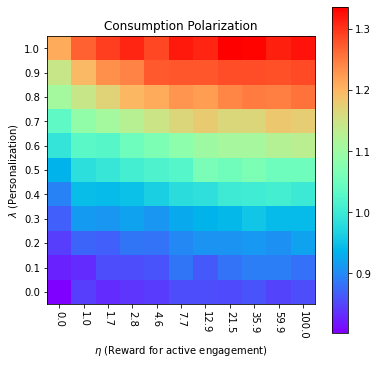

In [57]:
plt.figure(figsize=(6,6))
plt.title("Consumption Polarization")
plt.imshow(P_avg, cmap='rainbow')
plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
plt.ylabel('$\lambda$ (Personalization)')
plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(1), rotation=-90)
plt.xlabel('$\eta$ (Reward for active engagement)')
plt.colorbar()
plt.savefig(f'../Figures/png/polarization_grid.png')
plt.savefig(f'../Figures/polarization_grid.pdf')

In [ ]:
plt.figure(figsize=(9,9))
plt.title("Polarization std")
plt.imshow(P_std, cmap='rainbow')
plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
plt.ylabel('$\lambda$')
plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(0))
plt.xlabel('$\eta$')
plt.colorbar()
plt.savefig(f'../Figures/png/polarization_grid_std.png')

In [ ]:
Final_stancewise_avgrank_std[p][s][eta][lmb]

In [132]:
SAR_avg={p:{s:[] for s in POSSIBLE_STANCES} for p in [-1,0,1]}
SAR_std={p:{s:[] for s in POSSIBLE_STANCES} for p in [-1,0,1]}

for p in [-1,0,1]:
    for s in POSSIBLE_STANCES:
        for eta, data in Final_stancewise_avgrank_avg[p][s].items():
            SAR_avg[p][s].append([])
            SAR_std[p][s].append([])
            for lmb, sar in data.items():
                SAR_avg[p][s][-1].append(sar)
                SAR_std[p][s][-1].append(Final_stancewise_avgrank_std[p][s][eta][lmb])

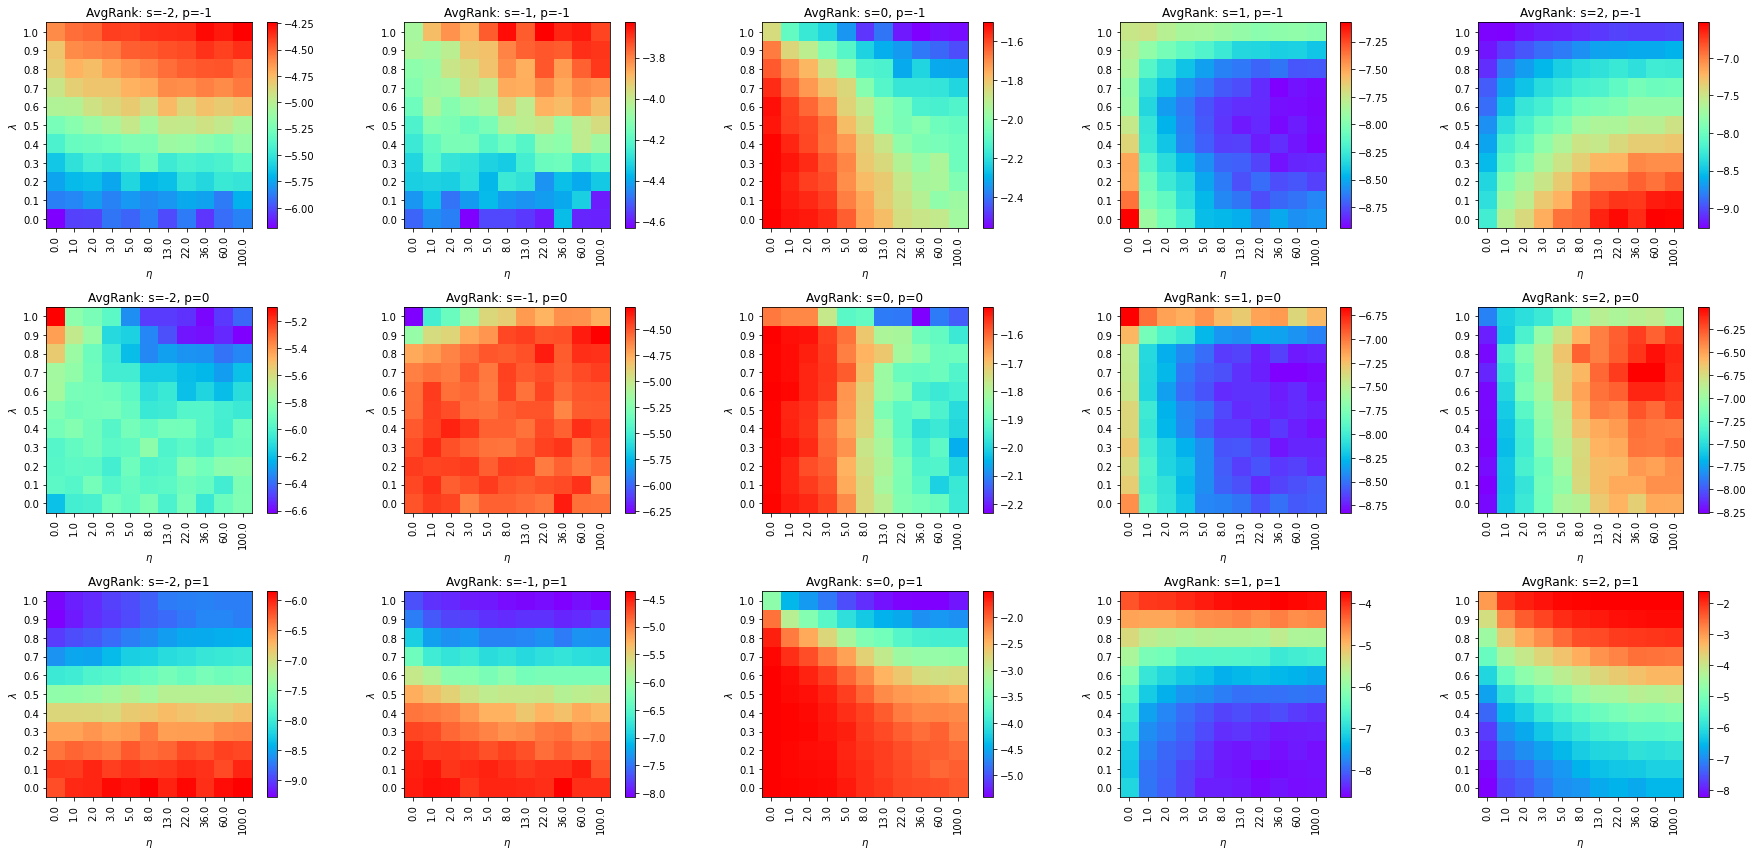

In [ ]:
plt.figure(figsize=(25,12))

plot_count=0
for partition in [-1,0,1]:
    for stance in POSSIBLE_STANCES:
        plot_count+=1
        plt.subplot(3,4,plot_count)
        plt.imshow(-np.array(SAR_avg[partition][stance]), cmap='rainbow')
        plt.title(f"AvgRank: s={stance}, p={partition}")
        plt.yticks(range(len(TEST_LAMBDA)), (1-np.array(TEST_LAMBDA)).round(1))
        plt.ylabel('$\lambda$')
        plt.xticks(range(len(TEST_ETA)), np.array(TEST_ETA).round(0), rotation=90)
        plt.xlabel('$\eta$')
        plt.colorbar()
plt.tight_layout()
plt.savefig(f'../Figures/png/AvgRanks.png')